# 1. Library import

In [1]:
import sys
sys.path.insert(0, "volatility-pipeline")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import kstest, skew, kurtosis

from volatility_pipeline.models import GARCHModel
from volatility_pipeline.evaluation import (
    RollingEvaluator,
    ForecastResult,
    dm_matrix,
    mcs,
)

# 2. Notebook variables set up

In [2]:
# ── Input data variables ────────────────────────────────────────────────────
TICKER          = "BZ=F"
FULL_DATA_START = "2010-01-01"
FULL_DATA_END   = "2026-05-28"

TRAIN_START = FULL_DATA_START
TRAIN_END   = "2022-06-30"
TEST_START  = "2022-07-01"
TEST_END    = FULL_DATA_END

# ── Classical econometric model specifications ───────────────────────────────
# Each tuple: (model_type, error_distribution)
# model_type:  'GARCH' | 'GJR-GARCH' | 'EGARCH' | 'APARCH' | 'FIGARCH'
# dist:        'normal' | 't' | 'ged'
GARCH_SPECS = [
    ("GARCH",     "normal"),
    ("GARCH",     "t"),
    ("GARCH",     "ged"),
    ("GJR-GARCH", "normal"),
    ("GJR-GARCH", "t"),
    ("GJR-GARCH", "ged"),
    ("EGARCH",    "normal"),
    ("EGARCH",    "t"),
    ("EGARCH",    "ged"),
    ("APARCH",    "normal"),
    ("APARCH",    "t"),
    ("APARCH",    "ged"),
    ("FIGARCH",   "normal"),
    ("FIGARCH",   "t"),
    ("FIGARCH",   "ged"),
]

# ── Out-of-sample evaluation ─────────────────────────────────────────────────
N_AHEAD     = 1   # forecast horizon (steps ahead); only 1 is currently supported
REFIT_EVERY = 10  # re-estimate model parameters every N test steps

# ── Statistical tests ────────────────────────────────────────────────────────
TEST_LOSS = "qlike"  # loss for DM test & MCS: 'squared' | 'absolute' | 'qlike'
MCS_ALPHA = 0.05       # MCS significance level  (0.10 → 90 % MCS)
DM_ALPHA  = 0.05       # Diebold-Mariano rejection threshold

# 3. Import data

In [3]:
# Import data from Yahoo Finance
data = yf.download(TICKER, start=FULL_DATA_START, end=FULL_DATA_END)
close = data["Close"].squeeze()
returns = np.log(close / close.shift(1)).dropna()
returns.index = pd.PeriodIndex(returns.index, freq='D')

[*********************100%***********************]  1 of 1 completed


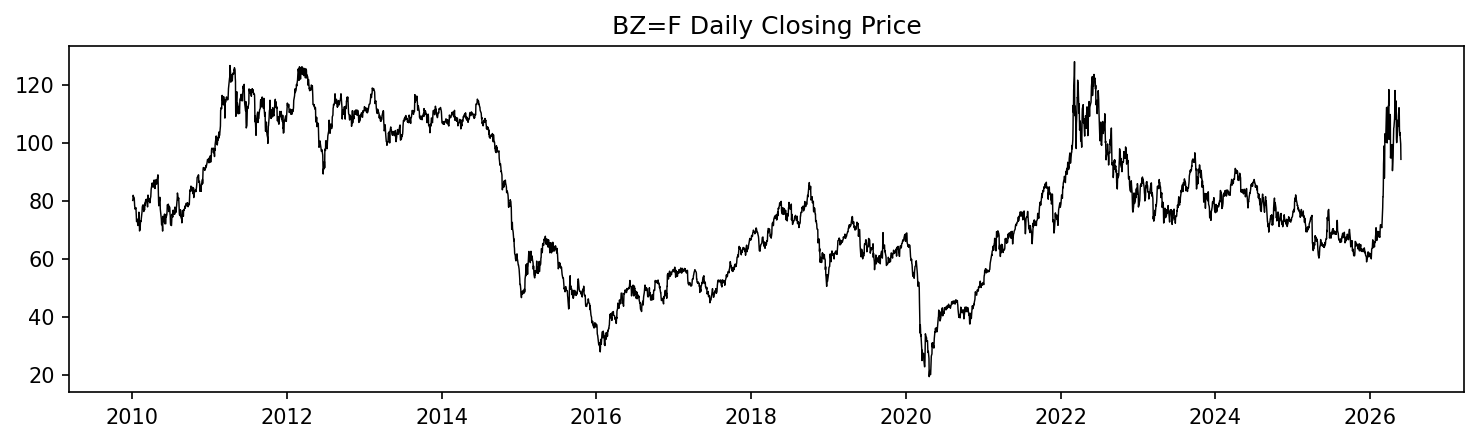

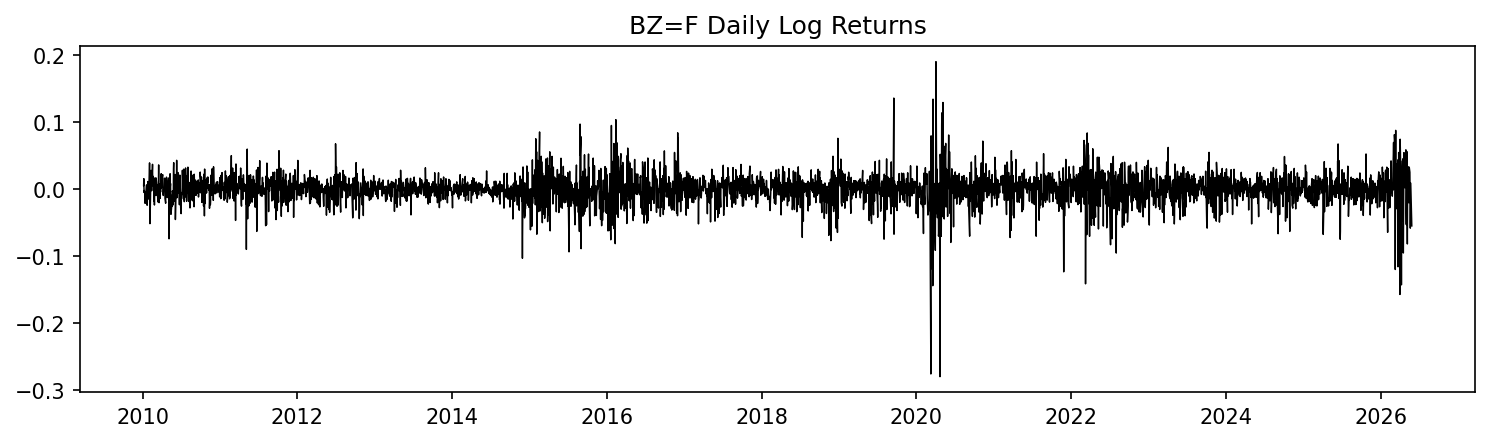

In [4]:
# Visualize the data
plt.figure(figsize=(12, 3), dpi=150)
plt.plot(close, linewidth=0.7, color='black')
plt.title(f"{TICKER} Daily Closing Price")
plt.show()

plt.figure(figsize=(12, 3), dpi=150)
plt.plot(returns.index.to_timestamp(), returns.values, label='Daily Returns', linewidth=0.7, color='black')
plt.title(f"{TICKER} Daily Log Returns")
plt.show()

In [5]:
def get_stats_and_ks(series, name):
    stats = series.describe()
    ks_stat, ks_pval = kstest(series, 'norm', args=(series.mean(), series.std()))
    result = {
        'count': stats['count'],
        'mean': stats['mean'],
        'std': stats['std'],
        'min': stats['min'],
        'max': stats['max'],
        'range': stats['max'] - stats['min'],
        'skewness': skew(series),
        'kurtosis': kurtosis(series),
        'KS_stat': ks_stat,
        'KS_pval': ks_pval,
        'Name': name
    }
    return result

stats_list = [
    get_stats_and_ks(returns, "Full Returns")
]

stats_df = pd.DataFrame(stats_list).set_index('Name')
stats_df


,count,mean,std,min,max,range,skewness,kurtosis,KS_stat,KS_pval
Name,,,,,,,,,,
Full Returns,4092.0,0.00004,0.023238,-0.279761,0.190774,0.470536,-0.998553,15.338745,0.086848,2.653574e-27


# 4. Classical Econometric Models (GARCH Family)

Five volatility specifications are estimated with three error distributions each (Normal, Student-t, GED), giving 15 models in total.

| Spec | Description |
|------|-------------|
| GARCH | Standard symmetric GARCH(1,1) — Bollerslev (1986) |
| GJR-GARCH | Asymmetric leverage effect via indicator term — Glosten et al. (1993) |
| EGARCH | Log-variance equation, asymmetric — Nelson (1991) |
| APARCH | Asymmetric power ARCH — Ding et al. (1993) |
| FIGARCH | Fractionally integrated long-memory variance — Baillie et al. (1996) |

## 4.1 In-sample fit

In [6]:
# Split returns into train / test using the date variables set above
train_returns = returns[returns.index <= TRAIN_END]
test_returns  = returns[returns.index >= TEST_START]

print(f"Train: {train_returns.index[0]}  →  {train_returns.index[-1]}  ({len(train_returns)} obs)")
print(f"Test:  {test_returns.index[0]}  →  {test_returns.index[-1]}  ({len(test_returns)} obs)")

Train: 2010-01-05  →  2022-06-30  (3110 obs)
Test:  2022-07-01  →  2026-05-27  (982 obs)


In [7]:
# Fit every model on training data and collect information criteria
insample_models: dict[str, GARCHModel] = {}
ic_rows = []

for model_type, dist in GARCH_SPECS:
    name = f"{model_type}-{dist.upper()}" 
    model = GARCHModel(model_type, dist)
    try:
        model.fit(train_returns)
        insample_models[name] = model
        row = model.info_criteria()
        row["Model"] = name
        ic_rows.append(row)
    except Exception as exc:
        print(f"  [WARNING] {name} failed in-sample fit: {exc}")

ic_df = (
    pd.DataFrame(ic_rows)
    .set_index("Model")
    .sort_values("BIC")
    [["LogL", "AIC", "BIC"]]
)
print(f"Fitted {len(insample_models)} / {len(GARCH_SPECS)} models")
ic_df

Fitted 15 / 15 models


,LogL,AIC,BIC
Model,,,
GJR-GARCH-T,-6264.173946,12540.347891,12576.602159
EGARCH-T,-6269.597063,12549.194126,12579.406016
GARCH-T,-6269.988512,12549.977024,12580.188914
APARCH-T,-6268.701121,12549.402242,12585.656510
FIGARCH-T,-6269.000674,12550.001349,12586.255617
GJR-GARCH-GED,-6276.601527,12565.203054,12601.457322
EGARCH-GED,-6282.924362,12575.848724,12606.060615
GARCH-GED,-6283.617069,12577.234138,12607.446028
APARCH-GED,-6282.159283,12576.318566,12612.572834


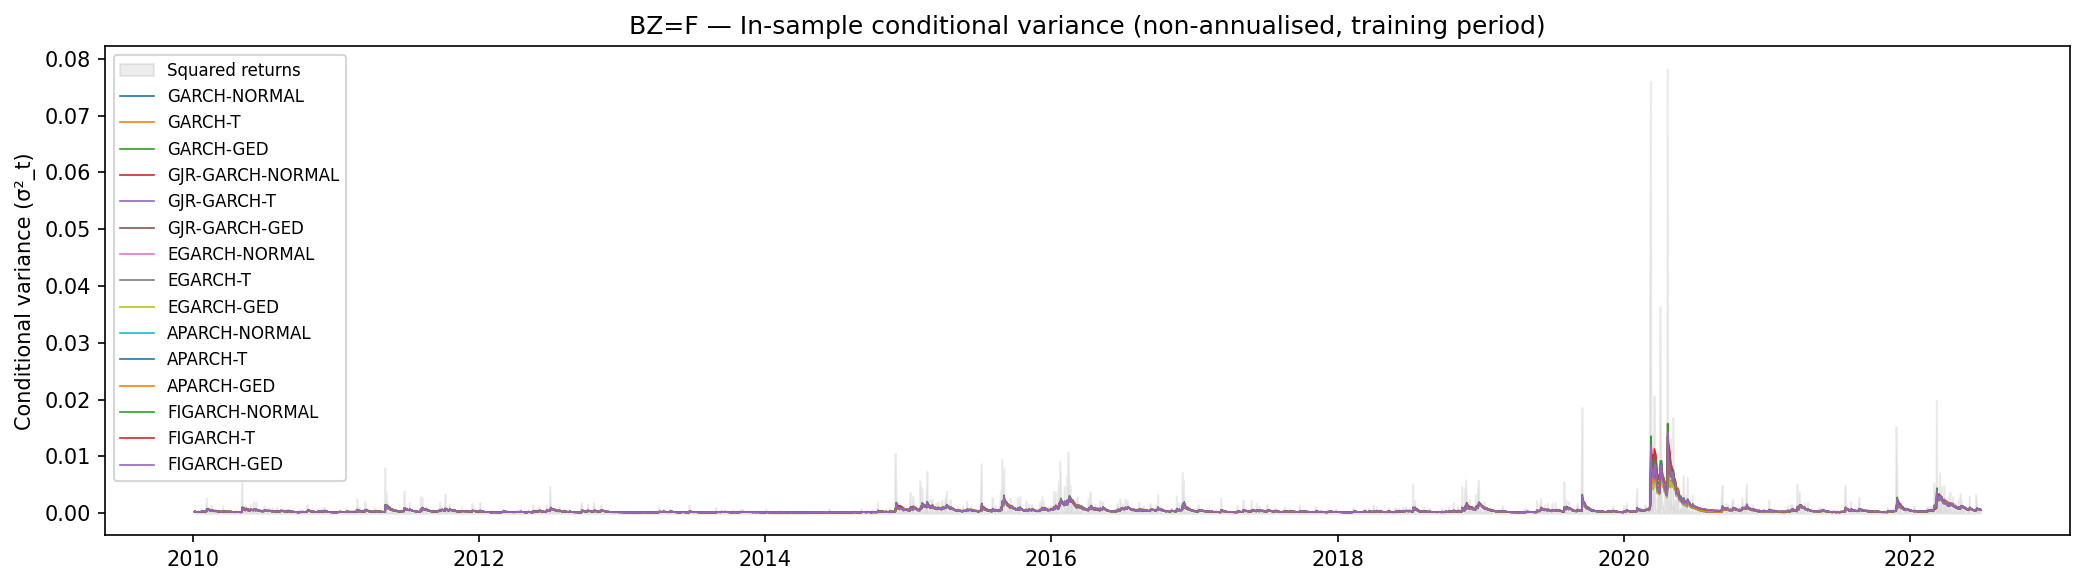

In [8]:
# In-sample conditional variance (non-annualised)
# Shows raw σ²_t as returned by each model
# PLOT_MODELS = ["GARCH-NORMAL", "GJR-GARCH-NORMAL", "EGARCH-NORMAL"]
PLOT_MODELS = [
    'GARCH-NORMAL', 'GARCH-T', 'GARCH-GED',
    'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED',
    'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED',
    'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED',
    'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED']

fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.fill_between(
    train_returns.index.to_timestamp(),
    train_returns.values ** 2,
    alpha=0.15, color="gray", label="Squared returns",
)
for name in PLOT_MODELS:
    if name in insample_models:
        cv = insample_models[name].insample_variance()
        ax.plot(
            cv.index.to_timestamp(),
            cv.values,
            linewidth=0.8,
            label=name,
        )
ax.set_title(f"{TICKER} — In-sample conditional variance (non-annualised, training period)")
ax.set_ylabel("Conditional variance (σ²_t)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

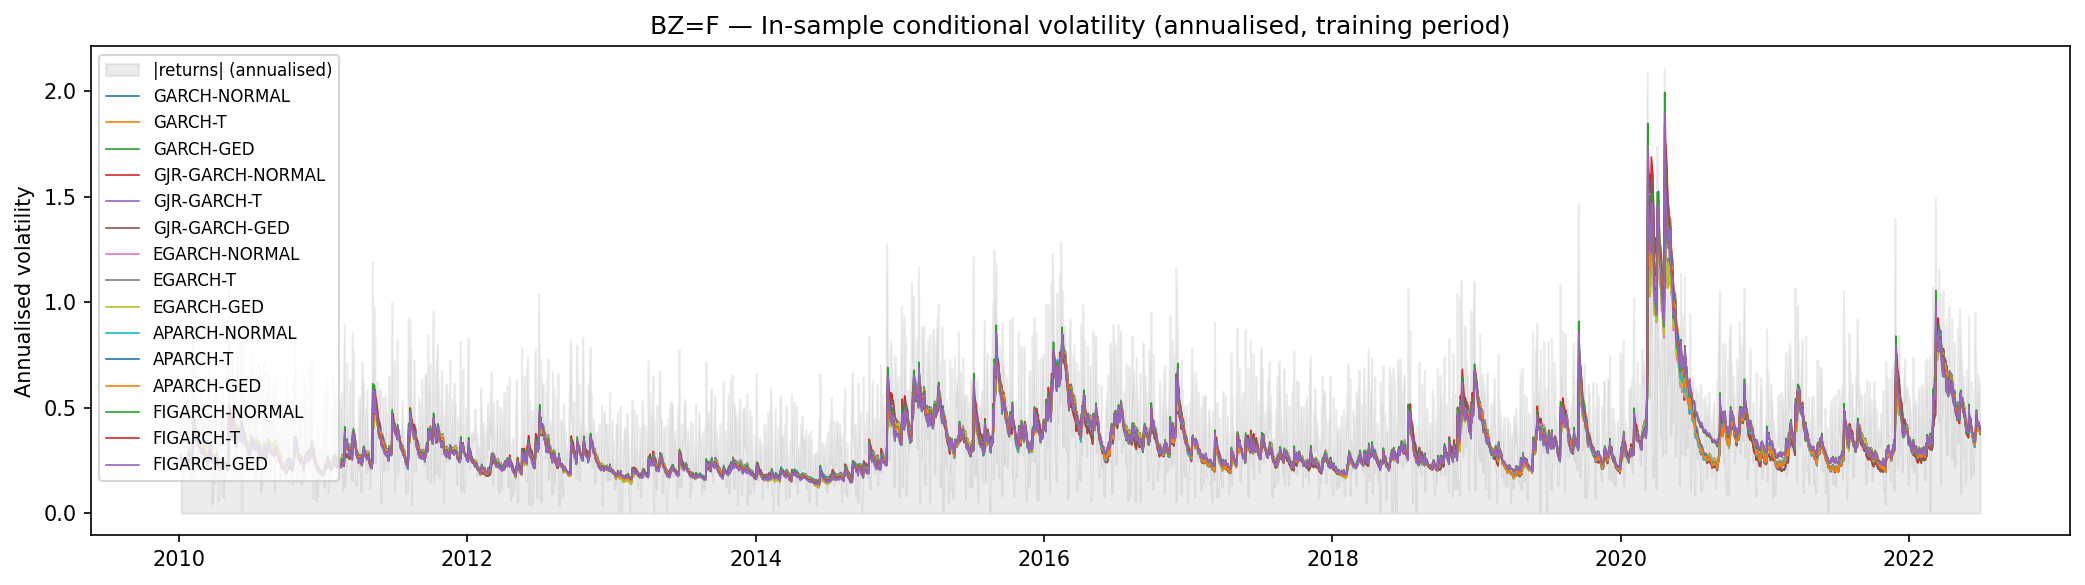

In [9]:
# In-sample conditional volatility — symmetric vs asymmetric comparison
# Shows annualised conditional standard deviation: sqrt(σ²_t × 252)
# PLOT_MODELS = ["GARCH-NORMAL", "GJR-GARCH-NORMAL", "EGARCH-NORMAL"]
PLOT_MODELS = [
    'GARCH-NORMAL', 'GARCH-T', 'GARCH-GED',
    'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED',
    'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED',
    'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED',
    'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED']

fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.fill_between(
    train_returns.index.to_timestamp(),
    np.sqrt(np.abs(train_returns.values) * np.sqrt(252)),
    alpha=0.15, color="gray", label="|returns| (annualised)",
)
for name in PLOT_MODELS:
    if name in insample_models:
        cv = insample_models[name].insample_variance()
        ax.plot(
            cv.index.to_timestamp(),
            np.sqrt(cv.values * 252),
            linewidth=0.8,
            label=name,
        )
ax.set_title(f"{TICKER} — In-sample conditional volatility (annualised, training period)")
ax.set_ylabel("Annualised volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4.2 Out-of-sample evaluation

Recursive one-step-ahead forecasting: at each step *t* the model is conditioned on all returns up to *t* and produces a forecast for *t+1*. Parameters are re-estimated every `REFIT_EVERY` steps (expanding window). The realized variance proxy is the squared log-return.

In [10]:
evaluator = RollingEvaluator(n_ahead=N_AHEAD, refit_every=REFIT_EVERY)

# Build (factory, name) pairs — default capture avoids late-binding closure issues
garch_eval_specs = [
    (lambda t=t, d=d: GARCHModel(t, d), f"{t}-{d.upper()}")
    for t, d in GARCH_SPECS
]

garch_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    garch_eval_specs, train_returns, test_returns, verbose=True
)
print(f"\nCompleted {len(garch_results)} models.")

Evaluating GARCH-NORMAL...
  [GARCH-NORMAL] re-fitted at step 0/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 10/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 20/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 30/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 40/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 50/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 60/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 70/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 80/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 90/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 100/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 110/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 120/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 130/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 140/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 150/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 160/982 (expanding)
  [GARCH-NORMAL] re-fitted at step 170/982 (expan

In [11]:
# Out-of-sample metrics table — ranked by RMSE
metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in garch_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
metrics_df

,RMSE,MAE,MSE,QLIKE
EGARCH-T,0.001424,0.000592,0.000002,-6.573449
EGARCH-GED,0.001424,0.000587,0.000002,-6.565022
EGARCH-NORMAL,0.001426,0.000594,0.000002,-6.553742
APARCH-GED,0.001431,0.000591,0.000002,-6.566444
APARCH-T,0.001432,0.000592,0.000002,-6.575043
APARCH-NORMAL,0.001435,0.000600,0.000002,-6.558086
GARCH-GED,0.001437,0.000595,0.000002,-6.566567
GARCH-T,0.001439,0.000600,0.000002,-6.575264
FIGARCH-GED,0.001440,0.000595,0.000002,-6.550407
GARCH-NORMAL,0.001441,0.000603,0.000002,-6.560343


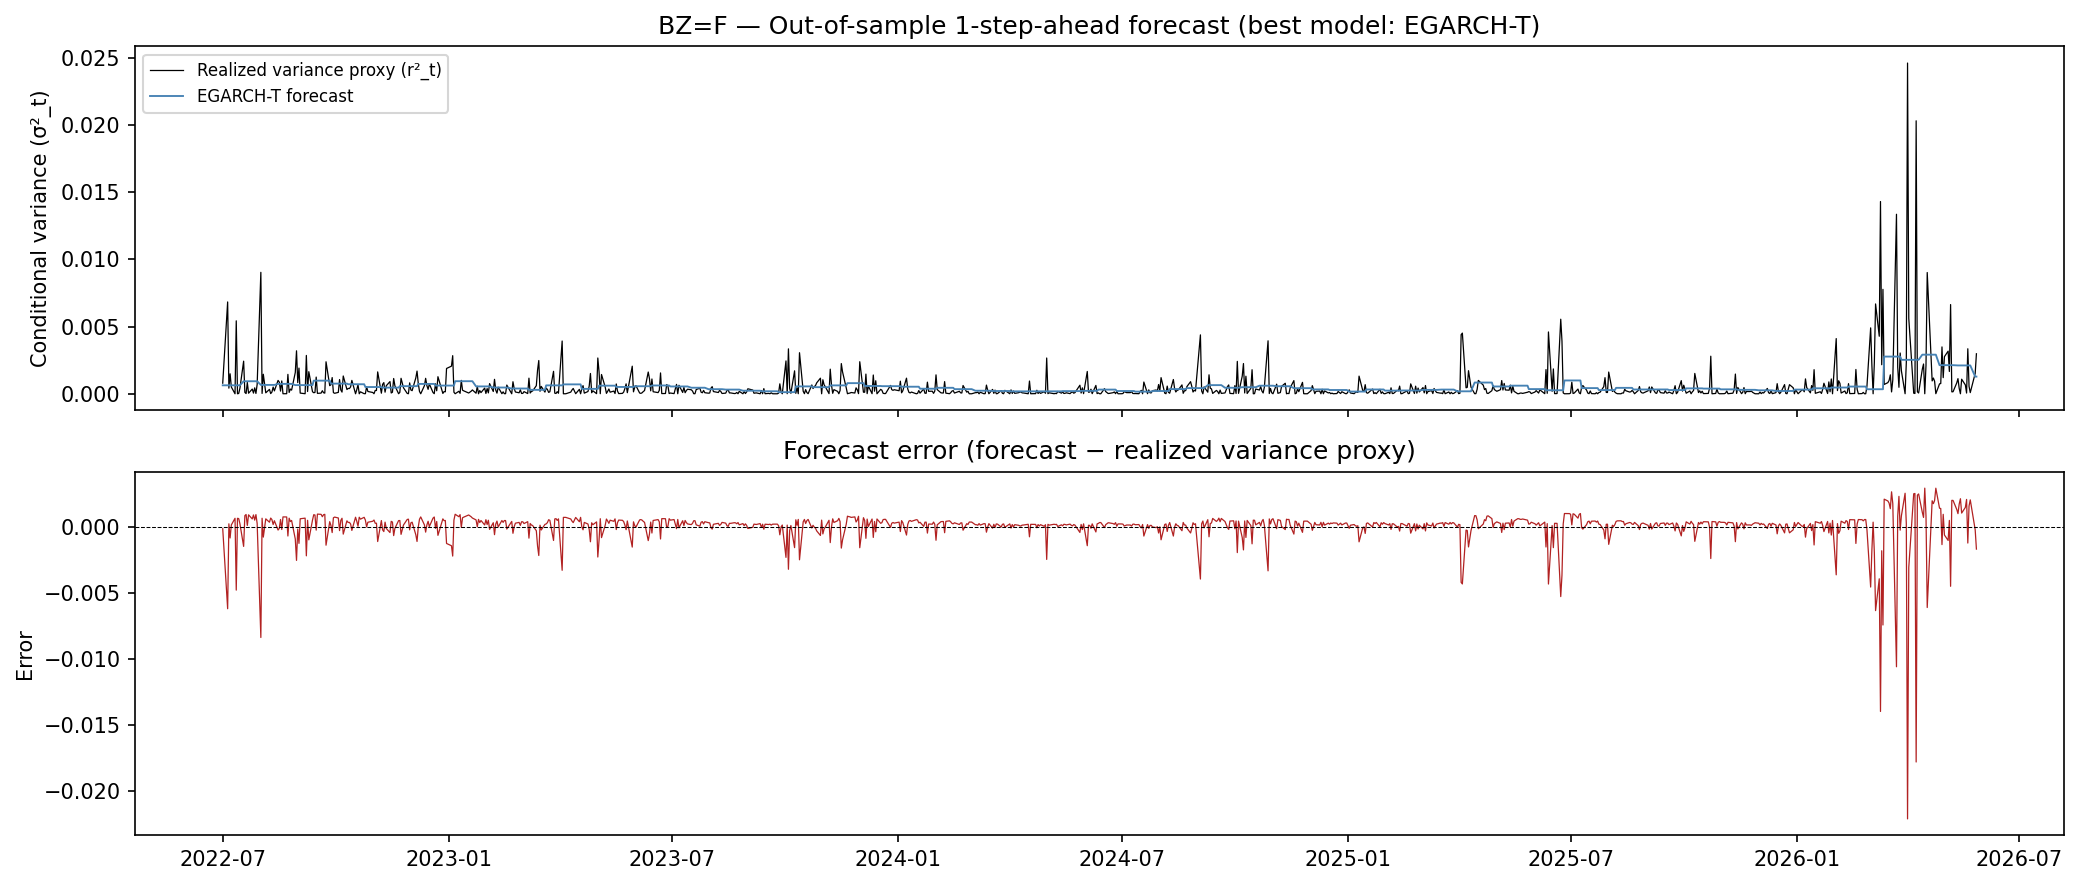

In [12]:
# Forecast vs realized — best model by RMSE (non-annualised)
# Shows raw variance: σ²_t forecast vs squared-return proxy
best_name = metrics_df.index[0]
r = garch_results[best_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)

ax0, ax1 = axes
ax0.plot(
    r.actuals.index.to_timestamp(),
    r.actuals.values,
    color="black", linewidth=0.6, label="Realized variance proxy (r²_t)",
)
ax0.plot(
    r.forecasts.index.to_timestamp(),
    r.forecasts.values,
    color="steelblue", linewidth=0.9, label=f"{best_name} forecast",
)
ax0.set_title(f"{TICKER} — Out-of-sample 1-step-ahead forecast (best model: {best_name})")
ax0.set_ylabel("Conditional variance (σ²_t)")
ax0.legend(fontsize=8)

ax1.plot(
    r.errors.index.to_timestamp(),
    r.errors.values,
    color="firebrick", linewidth=0.6,
)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_title("Forecast error (forecast − realized variance proxy)")
ax1.set_ylabel("Error")

plt.tight_layout()
plt.show()

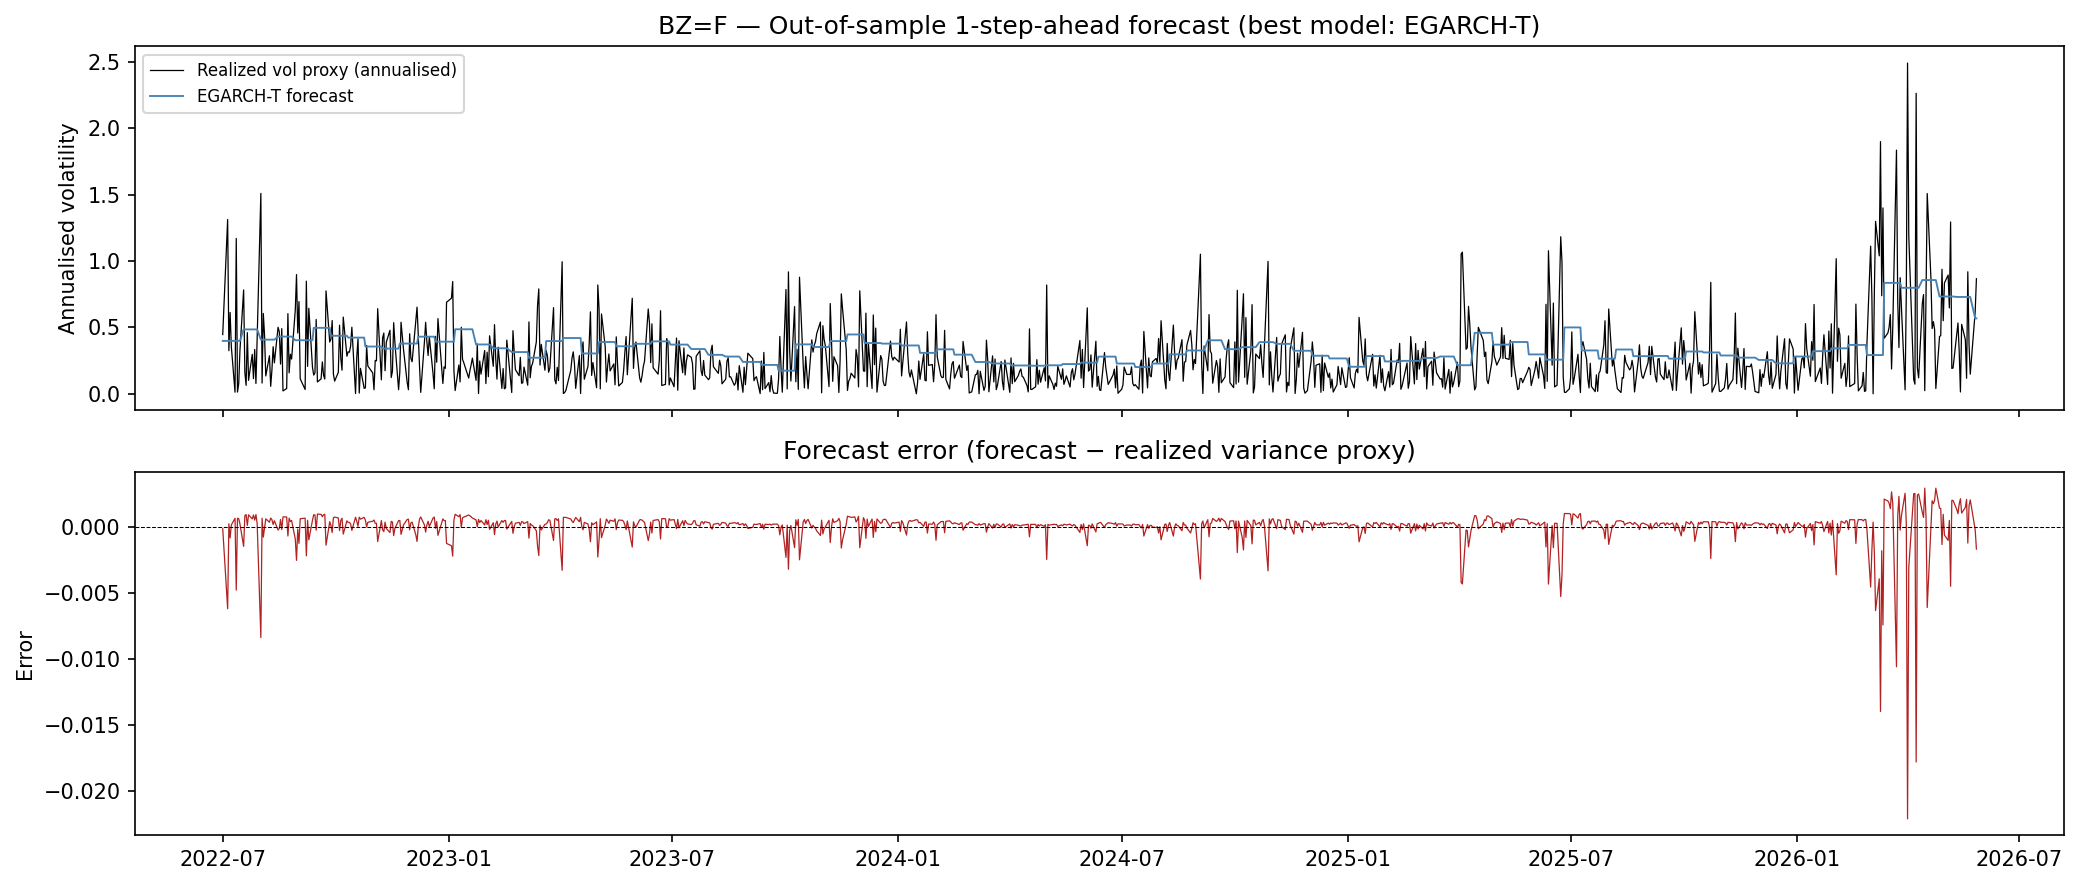

In [13]:
# Forecast vs realized — best model by RMSE
best_name = metrics_df.index[0]
r = garch_results[best_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)

ax0, ax1 = axes
ax0.plot(
    r.actuals.index.to_timestamp(),
    np.sqrt(r.actuals.values * 252),
    color="black", linewidth=0.6, label="Realized vol proxy (annualised)",
)
ax0.plot(
    r.forecasts.index.to_timestamp(),
    np.sqrt(r.forecasts.values * 252),
    color="steelblue", linewidth=0.9, label=f"{best_name} forecast",
)
ax0.set_title(f"{TICKER} — Out-of-sample 1-step-ahead forecast (best model: {best_name})")
ax0.set_ylabel("Annualised volatility")
ax0.legend(fontsize=8)

ax1.plot(
    r.errors.index.to_timestamp(),
    r.errors.values,
    color="firebrick", linewidth=0.6,
)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_title("Forecast error (forecast − realized variance proxy)")
ax1.set_ylabel("Error")

plt.tight_layout()
plt.show()

# 5. Statistical Tests

## 5.1 Diebold-Mariano Test (HLN correction)

Pairwise test of equal predictive accuracy (Harvey, Leybourne & Newbold 1997).  
H₀: models *i* and *j* have equal expected loss.  
Negative MDM statistic → row model has lower loss than column model.  
p-values are two-sided from a *t*(T−1) distribution.

In [14]:
dm_stat_df, dm_pval_df = dm_matrix(garch_results, h=N_AHEAD, loss=TEST_LOSS)

print("MDM statistics (upper triangle):")
dm_stat_df.round(3)

MDM statistics (upper triangle):


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED
GARCH-NORMAL,NaN,3.06,2.241,-3.479,0.145,-1.523,-0.535,1.144,0.417,-0.561,3.526,1.654,-1.190,-0.227,-0.756
GARCH-T,NaN,NaN,-2.952,-4.180,-2.731,-3.494,-1.547,-0.159,-0.841,-2.275,-0.053,-1.520,-1.766,-1.180,-1.495
GARCH-GED,NaN,NaN,NaN,-4.183,-1.051,-2.906,-0.967,0.581,-0.130,-1.440,2.084,-0.028,-1.407,-0.647,-1.064
GJR-GARCH-NORMAL,NaN,NaN,NaN,NaN,3.861,3.824,1.219,2.645,2.181,2.881,4.492,4.101,0.275,1.329,0.784
GJR-GARCH-T,NaN,NaN,NaN,NaN,NaN,-3.289,-0.596,1.083,0.329,-0.405,2.356,0.817,-0.961,-0.222,-0.616
GJR-GARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,0.240,1.828,1.214,0.999,3.464,2.482,-0.429,0.442,-0.018
EGARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.769,4.345,0.498,2.092,1.385,-0.697,0.265,-0.215
EGARCH-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.741,-1.745,0.199,-0.841,-1.813,-1.053,-1.414
EGARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.875,1.189,0.182,-1.412,-0.510,-0.954
APARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.917,3.505,-1.185,-0.038,-0.652


In [15]:
print("DM p-values (upper triangle) — highlighted cells: p < DM_ALPHA")
dm_pval_df.round(4).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold"
    if (not pd.isna(v) and v < DM_ALPHA)
    else "",
)

DM p-values (upper triangle) — highlighted cells: p < DM_ALPHA


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED
GARCH-NORMAL,nan,0.002300,0.025200,0.000500,0.885000,0.128100,0.592500,0.252900,0.676700,0.575100,0.000400,0.098400,0.234300,0.820700,0.449900
GARCH-T,nan,nan,0.003200,0.000000,0.006400,0.000500,0.122200,0.873900,0.400800,0.023100,0.957500,0.129000,0.077700,0.238200,0.135300
GARCH-GED,nan,nan,nan,0.000000,0.293700,0.003700,0.333700,0.561200,0.896300,0.150100,0.037400,0.977800,0.159900,0.518100,0.287600
GJR-GARCH-NORMAL,nan,nan,nan,nan,0.000100,0.000100,0.223200,0.008300,0.029400,0.004100,0.000000,0.000000,0.783200,0.184000,0.433400
GJR-GARCH-T,nan,nan,nan,nan,nan,0.001000,0.551500,0.279000,0.742600,0.685600,0.018700,0.414100,0.336800,0.824700,0.538000
GJR-GARCH-GED,nan,nan,nan,nan,nan,nan,0.810600,0.067900,0.225100,0.318100,0.000600,0.013200,0.668300,0.658900,0.985500
EGARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,0.000200,0.000000,0.618900,0.036700,0.166300,0.486000,0.791200,0.830000
EGARCH-T,nan,nan,nan,nan,nan,nan,nan,nan,0.006200,0.081300,0.842600,0.400700,0.070200,0.292600,0.157700
EGARCH-GED,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.381600,0.234800,0.856000,0.158400,0.610000,0.340400
APARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000100,0.000500,0.236400,0.969700,0.514500


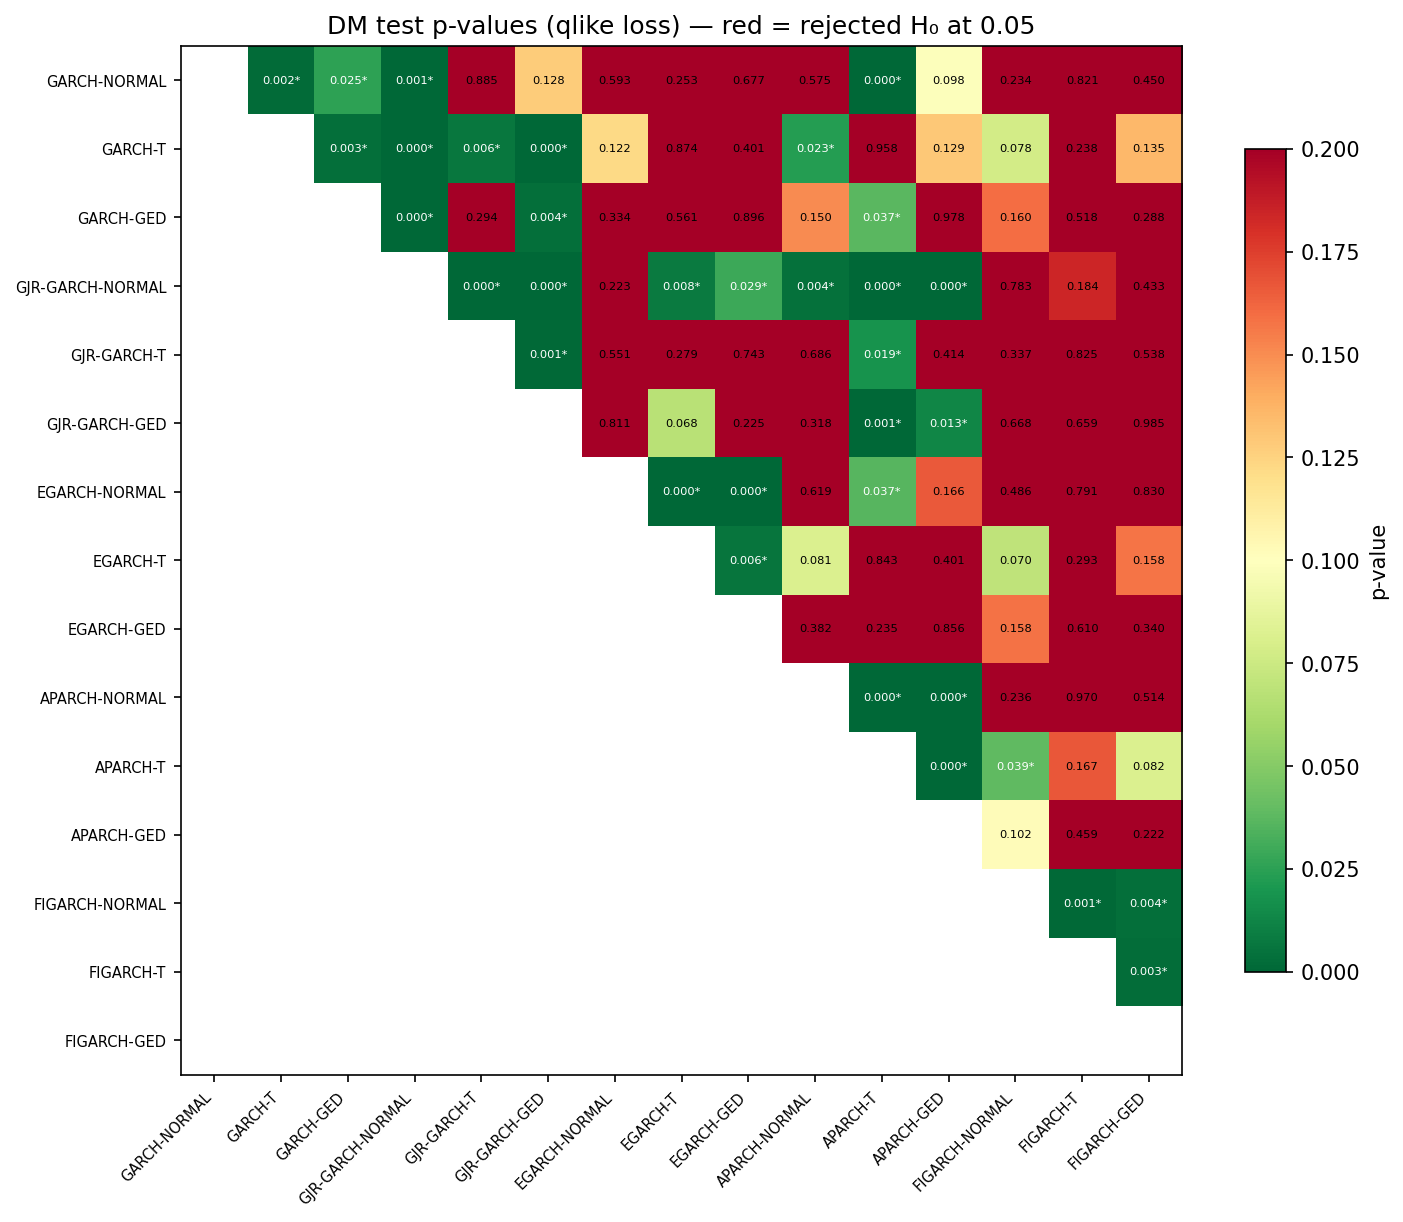

In [16]:
# DM p-value heatmap (upper triangle only)
names  = list(garch_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)

# Mask lower triangle + diagonal (show upper triangle only)
mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)

fig, ax = plt.subplots(figsize=(max(8, n_mods * 0.65), max(6, n_mods * 0.55)), dpi=150)
im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
plt.colorbar(im, ax=ax, label="p-value", shrink=0.8)

ax.set_xticks(range(n_mods))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_mods))
ax.set_yticklabels(names, fontsize=7)
ax.set_title(f"DM test p-values ({TEST_LOSS} loss) — red = rejected H₀ at {DM_ALPHA}")

for i in range(n_mods):
    for j in range(i + 1, n_mods):
        v = pvals[i, j]
        if not np.isnan(v):
            sig = "*" if v < DM_ALPHA else ""
            ax.text(j, i, f"{v:.3f}{sig}", ha="center", va="center", fontsize=5.5,
                    color="white" if v < 0.05 else "black")

plt.tight_layout()
plt.show()

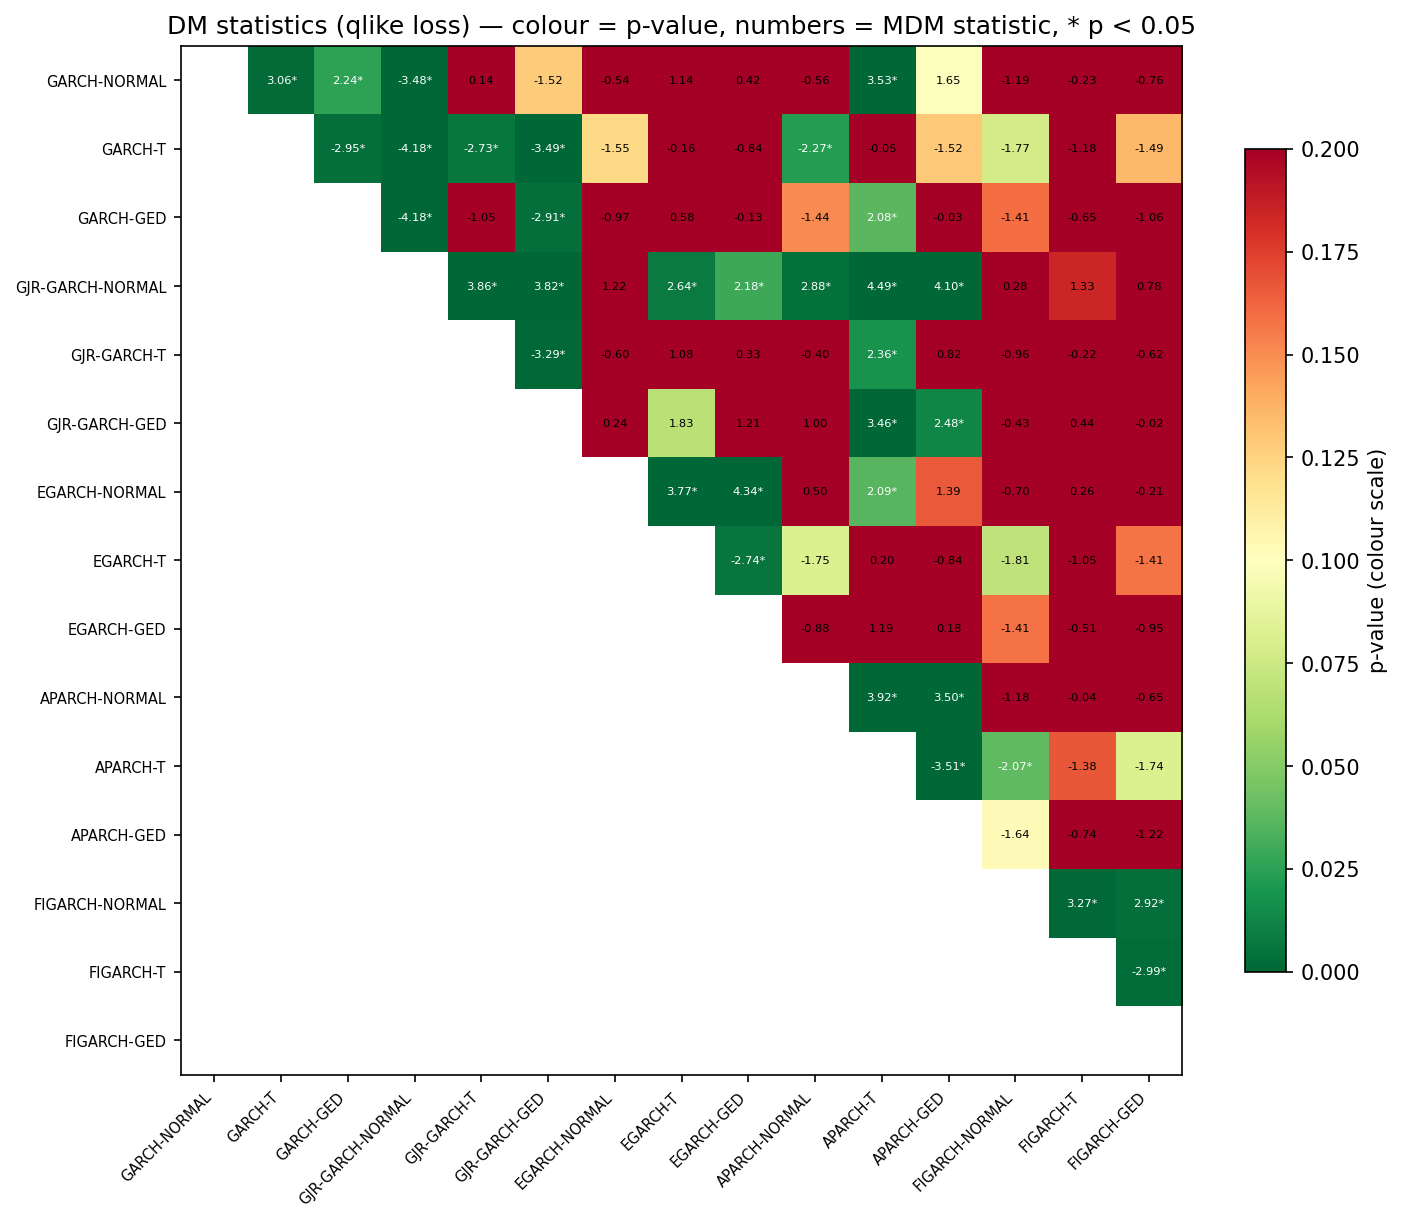

In [17]:
# DM statistics heatmap — colour based on p-value, numbers show DM statistic
names  = list(garch_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)
stats  = dm_stat_df.values.astype(float)

mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)
stats_plot = np.where(mask, np.nan, stats)

fig, ax = plt.subplots(figsize=(max(8, n_mods * 0.65), max(6, n_mods * 0.55)), dpi=150)
im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
plt.colorbar(im, ax=ax, label="p-value (colour scale)", shrink=0.8)

ax.set_xticks(range(n_mods))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_mods))
ax.set_yticklabels(names, fontsize=7)
ax.set_title(f"DM statistics ({TEST_LOSS} loss) — colour = p-value, numbers = MDM statistic, * p < {DM_ALPHA}")

for i in range(n_mods):
    for j in range(i + 1, n_mods):
        s = stats_plot[i, j]
        p = pvals_plot[i, j]
        if not np.isnan(s):
            sig = "*" if p < DM_ALPHA else ""
            ax.text(j, i, f"{s:.2f}{sig}", ha="center", va="center", fontsize=5.5,
                    color="white" if p < 0.05 else "black")

plt.tight_layout()
plt.show()

## 5.2 Model Confidence Set (MCS)

Hansen, Lunde & Nason (2011). Sequential elimination of the worst model using the T_max statistic until the null of equal predictive accuracy cannot be rejected. Inference via stationary bootstrap (Politis & Romano 1994).

Models with `mcs_pvalue > MCS_ALPHA` belong to the (1 − MCS_ALPHA) MCS.

In [18]:
mcs_result = mcs(
    garch_results,
    loss=TEST_LOSS,
    alpha=MCS_ALPHA,
    n_boot=2000, 
    seed=42,
)
print(mcs_result)
print()
mcs_result.summary().style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["in_mcs"],
).format({"mcs_pvalue": "{:.4f}"})

MCSResult(alpha=0.05, loss='qlike', n_included=15, models=['GARCH-NORMAL', 'GARCH-T', 'GARCH-GED', 'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED', 'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED', 'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED', 'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED'])



,mcs_pvalue,in_mcs
GARCH-NORMAL,1.0000,True
GARCH-T,1.0000,True
GARCH-GED,1.0000,True
GJR-GARCH-NORMAL,1.0000,True
GJR-GARCH-T,1.0000,True
GJR-GARCH-GED,1.0000,True
EGARCH-NORMAL,1.0000,True
EGARCH-T,1.0000,True
EGARCH-GED,1.0000,True
APARCH-NORMAL,1.0000,True
